<a href="https://colab.research.google.com/github/Neerajvishwakarma90/zomato-data-analysis/blob/main/zomato_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
data = pd.read_csv('/content/Zomato-data-.csv')
data

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [3]:
data

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [4]:
data['New_rate'] = data['rate']

In [5]:
data['New_rate'] = data['New_rate'].str.split('/')

In [6]:
data['rate']=data['New_rate'].apply(lambda x:x[0])

In [7]:
data['rate']

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
...,...
143,3.3
144,3.3
145,4.0
146,3.0


In [8]:
data.drop(columns='New_rate', inplace=True)

In [9]:
data

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


In [10]:
data.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [12]:
data.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [14]:
os.makedirs("images",exist_ok=True)

/tmp/ipykernel_945/3476689545.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['listed_in(type)'],palette='dark')


Text(0.5, 23.52222222222222, 'types of restaurant')

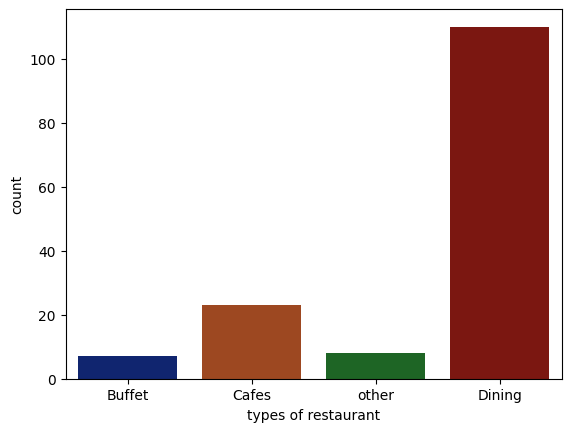

In [15]:
sns.countplot(x=data['listed_in(type)'],palette='dark')
plt.savefig("images/count_of_restaurents")
plt.xlabel('types of restaurant')

In [ ]:
group_data = data.groupby('listed_in(type)')['votes'].sum()

In [ ]:
result = pd.DataFrame({'votes': group_data})

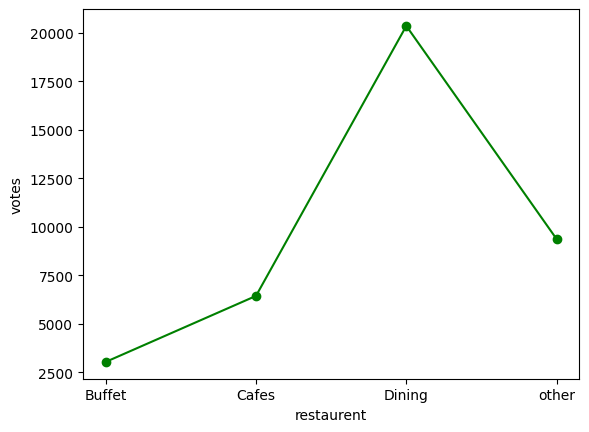

In [ ]:
plt.plot(result, c='green',marker='o')
plt.xlabel('restaurent')
plt.ylabel('votes')
plt.show()

In [ ]:
max = data['votes'].max()
restaurant_with_max_vote = data.loc[data['votes'] == max,'name']
restaurant_with_max_vote

,name
38,Empire Restaurant


<Axes: xlabel='online_order', ylabel='count'>

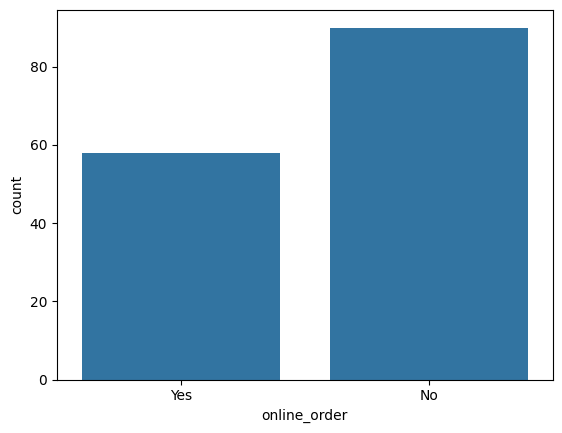

In [ ]:
sns.countplot(x = data['online_order'])

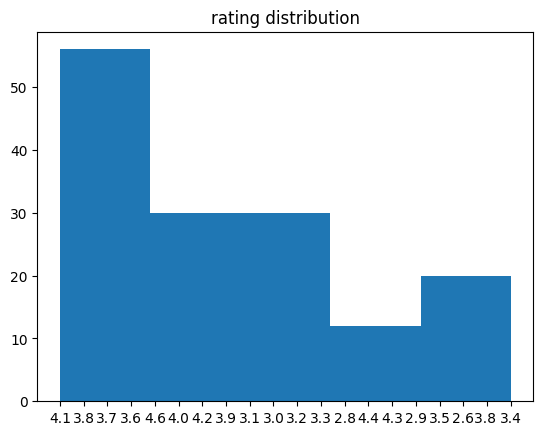

In [ ]:
plt.hist(data['rate'],bins=5)
plt.title("rating distribution")
plt.show()

<Axes: title={'center': 'approx cost of couple'}, xlabel='approx_cost(for two people)', ylabel='count'>

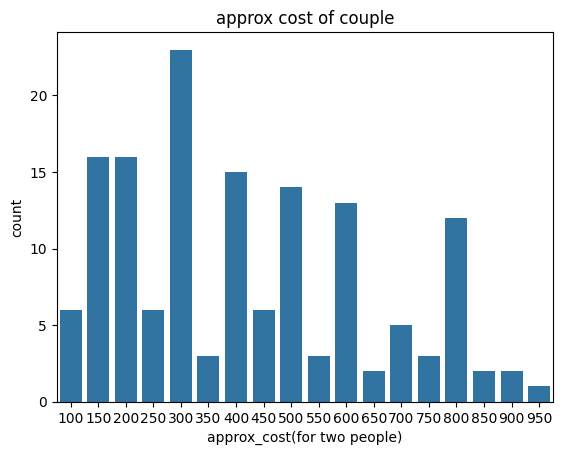

In [ ]:
couple_data = data['approx_cost(for two people)']
plt.title('approx cost of couple')
sns.countplot(x = couple_data)

<Axes: title={'center': 'online and offline rating comparession'}, xlabel='online_order', ylabel='rate'>

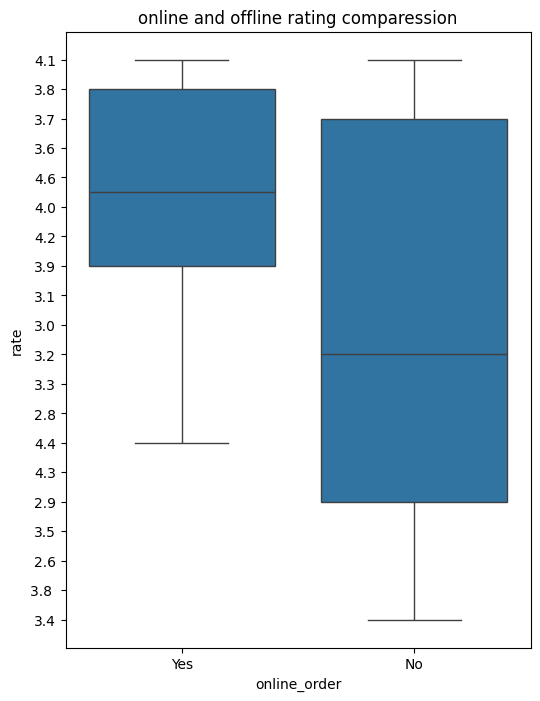

In [ ]:
plt.figure(figsize=(6,8))
plt.title('online and offline rating comparession')
sns.boxplot(x = 'online_order', y = 'rate' , data=data)

Text(50.722222222222214, 0.5, 'types of restaurants')

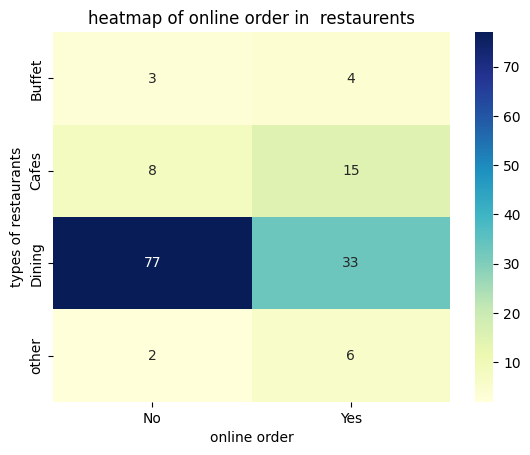

In [ ]:
pivot_table = data.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size' , fill_value=0)
sns.heatmap(pivot_table, annot=True,cmap='YlGnBu')
plt.title('heatmap of online order in  restaurents')
plt.xlabel("online order")
plt.ylabel("types of restaurants")